In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
while not (ROOT / "backtest").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
HERE = ROOT / "research" / "regime_detection"
OUT = ROOT / "out" / "regime_detection"
sys.path[:0] = [str(ROOT)]

from research.regime_detection.features import FEATURES, build_features, widened_features
from research.regime_detection import pipeline as pl
from research.regime_detection.pipeline import BULL, BEAR

pd.set_option("display.width", 170, "display.max_columns", 40)
print("repo:     ", ROOT)
print("artefacts:", OUT, "->", "present" if (OUT / "summary.json").exists() else "MISSING - run run_replication.py")

repo:      /Users/kunjshah/Downloads/pxq_stocks
artefacts: /Users/kunjshah/Downloads/pxq_stocks/out/regime_detection -> present


In [2]:
# ---- chart styling -------------------------------------------------------
# Same validated palette the other notebooks in this repo use: categorical hues
# assigned in fixed order, never cycled, and checked for colour-vision deficiency.
SERIES = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2.0,
})

# Regime identity is fixed to the entity, not to rank or row order.
HUE = {BULL: SERIES["blue"], BEAR: SERIES["orange"]}
pct = FuncFormatter(lambda x, _: f"{x:.0%}")

def end_label(ax, series, text, color, dx=6):
    '''Direct label at the end of a line, so identity is never colour-alone.'''
    y = series.dropna().iloc[-1]
    ax.annotate(text, xy=(series.dropna().index[-1], y), xytext=(dx, 0),
                textcoords="offset points", color=color, fontsize=10,
                fontweight="bold", va="center")

def compare(ours, paper, index, label_ours="this replication", label_paper="paper"):
    '''Put our number next to theirs in one frame -- never one without the other.'''
    return pd.DataFrame({label_paper: paper, label_ours: ours}, index=index)

## 1 — The data, and the three places it does not come from Alpaca

The paper needs four daily series. This repo's rule is *historical → Alpaca*
([`data-routing`](../../.claude/skills/data-routing/SKILL.md)), and for two of the four
Alpaca has nothing to serve: it carries no index data and no macro data.

| Series | Source | Why not Alpaca |
|---|---|---|
| S&P 500 level + volume | Alpaca `SPY` `1Day`, `adjustment="raw"` | — |
| WTI crude | Alpaca `USL` `1Day` (12-month oil fund) | Alpaca has no futures; `USO` is not served |
| VIX close | Cboe `VIX_History.csv` | **no index data** — the VIX is not a tradable equity |
| 10-year UST yield | FRED `DGS10` | **no macro data** |

Both CSVs come from the series' own publisher — Cboe computes the VIX, the St. Louis Fed
publishes DGS10 — over one scripted HTTP GET each, so the whole panel regenerates from
`fetch_data.py`. The rule they brush against is aimed at *pricing an order* off a scraped
quote, which is a different risk from reading a published index history into a research
notebook. Nothing here ever reaches an order.

**`adjustment="raw"`, not the repo default `"all"`.** Four of the paper's features are a
distance from a moving average or a drawdown from a running maximum, computed on an S&P 500
*price* level. Dividend-adjusting SPY restates that level and shifts every one of them.

**The window.** The paper runs 2010-10-18 → 2025-12-31 (n = 3,823). Alpaca equity history
begins **2016-01-04**, and Volume_Ratio needs SPY volume, so the replication runs
2016-01-04 → today — about 65% of the paper's sample, and it still contains Q4 2018, the
COVID crash, 2022, and a stretch past the paper's own end date.

In [3]:
panel = pd.read_parquet(ROOT / "data" / "regime_panel.parquet")
print(f"{len(panel):,} sessions   {panel.index.min().date()} -> {panel.index.max().date()}")
print("missing values:", panel.isna().sum().sum())
display(panel.describe().T[["count", "mean", "min", "max"]].round(2))
display(panel.head(3))

2,693 sessions   2016-01-04 -> 2026-09-18
missing values: 0


,count,mean,min,max
close,2693.0,399.14,182.86,7.778800e+02
volume,2693.0,82439497.28,20550098.00,3.948250e+08
oil_close,2693.0,27.99,9.61,5.754000e+01
VIX,2693.0,18.49,9.14,8.269000e+01
DGS10,2693.0,2.81,0.52,5.010000e+00


,close,volume,oil_close,VIX,DGS10
date,,,,,
2016-01-04,201.0192,225903783.0,16.9990,20.70,2.24
2016-01-05,201.3600,112719152.0,16.6222,19.34,2.25
2016-01-06,198.8200,153948196.0,16.0000,20.59,2.18


## 2 — Features: the paper says sixteen, and names fifteen

Section IV lists the clustering feature set explicitly. Counted, the list is **fifteen**:

`Return`, `Log_Return`, `Volatility_20D`, `Volatility_60D`, `Momentum_20D`,
`Momentum_60D`, `Distance_MA50`, `Distance_MA200`, `Drawdown`, `Volume_Ratio`,
`VIX`, `VIX_Change`, `VIX_Ratio`, `Treasury_20D_Change`, `Oil_Return`

The abstract, Section IV's prose, and Table 2's "sixteen principal components" all say
sixteen. Table 9 — the Random Forest importances — lists **fourteen**, dropping
`Log_Return`. The paper's own three counts disagree, and there is no sixteenth variable
named anywhere in it. This replication uses the fifteen that are named, and reports the
discrepancy rather than inventing a feature to reach sixteen.

Everything here is **same-day by construction**, which is what the paper asks for: the
clustering is an explicitly contemporaneous description of a day (Section V.F), not a
signal. The one place a lag is mandatory — the forecasting target, and the strategy's
exposure — is applied in `pipeline.py`, where the causality claim is actually made, rather
than hidden inside a feature definition.

A 200-session warmup for `Distance_MA200` is unavoidable and those rows are dropped, not
back filled. That warmup incidentally fixes a second problem: our running maximum is
anchored at 2016-01-04 rather than the paper's 2010, which would understate early-2016
drawdowns — but SPY made new highs in July 2016, well inside the discarded window.

In [4]:
frame = build_features(panel)
print(f"{len(frame):,} observations   {frame.index.min().date()} -> {frame.index.max().date()}")
print(f"paper: 3,823 observations   2010-10-18 -> 2025-12-31   ({len(frame)/3823:.0%} of the sample)")
print(f"\n{len(FEATURES)} clustering features:", ", ".join(FEATURES))
display(frame[list(FEATURES)].describe().T[["mean", "std", "min", "max"]].round(4))

2,494 observations   2016-10-17 -> 2026-09-18
paper: 3,823 observations   2010-10-18 -> 2025-12-31   (65% of the sample)

15 clustering features: Return, Log_Return, Volatility_20D, Volatility_60D, Momentum_20D, Momentum_60D, Distance_MA50, Distance_MA200, Drawdown, Volume_Ratio, VIX, VIX_Change, VIX_Ratio, Treasury_20D_Change, Oil_Return


,mean,std,min,max
Return,0.0006,0.0112,-0.1078,0.1050
Log_Return,0.0005,0.0112,-0.1141,0.0999
Volatility_20D,0.1487,0.0991,0.0306,0.8761
Volatility_60D,0.1553,0.0879,0.0495,0.5866
Momentum_20D,0.0113,0.0447,-0.3120,0.2282
Momentum_60D,0.0330,0.0687,-0.3068,0.3996
Distance_MA50,0.0128,0.0379,-0.2795,0.1323
Distance_MA200,0.0512,0.0632,-0.2659,0.1723
Drawdown,-0.0473,0.0601,-0.3418,0.0000
Volume_Ratio,1.0063,0.3428,0.3236,3.4659


## 3 — PCA: one trend/risk axis, and one shock axis

Standardise on the training slice only, then keep the smallest number of components
reaching 90% cumulative variance. The paper needed eight for 92.1%.

In [5]:
fit = pl.fit_regimes(frame)
print(f"components retained: {fit.n_components}   "
      f"cumulative variance: {fit.explained_variance['cumulative'].iloc[fit.n_components-1]:.1%}")
print(f"paper:               8                    92.1%")
print(f"\ntrain/test split (chronological 70/30) at {fit.split_date.date()}")

display(compare(
    fit.explained_variance["explained_variance"].head(8).values,
    [0.3667, 0.1997, 0.0962, 0.0684, 0.0564, 0.0536, 0.0457, 0.0347],
    index=[f"PC{i}" for i in range(1, 9)],
).style.format("{:.2%}").set_caption("Explained variance per component — paper Table 2"))

components retained: 7   cumulative variance: 91.4%
paper:               8                    92.1%

train/test split (chronological 70/30) at 2023-09-22


,paper,this replication
PC1,36.67%,36.38%
PC2,19.97%,21.61%
PC3,9.62%,10.05%
PC4,6.84%,7.22%
PC5,5.64%,6.64%
PC6,5.36%,5.52%
PC7,4.57%,3.98%
PC8,3.47%,2.43%


PC1 is the paper's headline interpretation: a single **trend/risk axis** loading positively
on drawdown, moving-average distance and momentum, and negatively on VIX and realised
volatility. High PC1 = uptrending and calm; low PC1 = drawdown-heavy and volatile.

Loadings are signed, so the chart below uses the diverging pair — two hues either side of a
neutral zero line — rather than a single hue that would hide the sign.

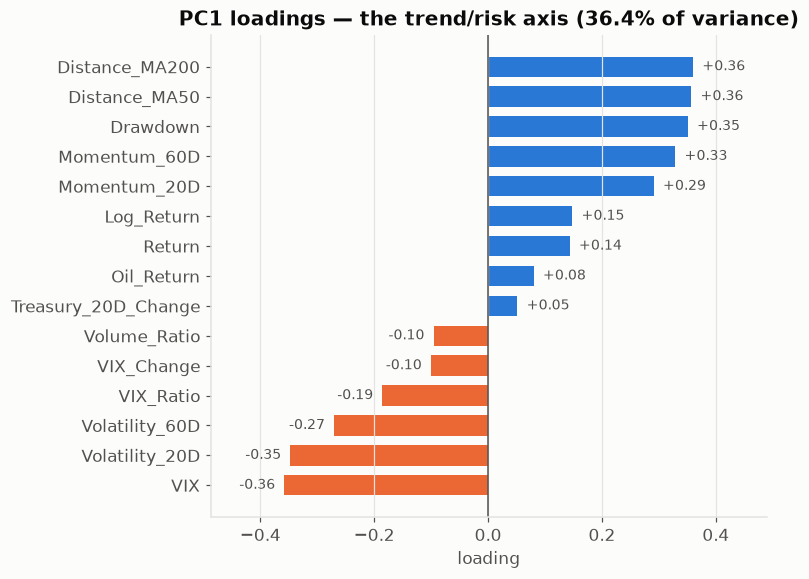

Paper's reported PC1 loadings:  Drawdown +0.379 · Distance_MA50 +0.347 · Distance_MA200 +0.341 · Momentum_60D +0.311 · VIX -0.338 · Volatility_20D -0.325


In [6]:
load = fit.loadings["PC1"].sort_values()
fig, ax = plt.subplots(figsize=(7.2, 5.4))
colors = [SERIES["orange"] if v < 0 else SERIES["blue"] for v in load]
ax.barh(load.index, load.values, color=colors, height=0.68)
ax.axvline(0, color=INK_2, lw=1.0)
ax.set_title(f"PC1 loadings — the trend/risk axis ({fit.explained_variance['explained_variance'].iloc[0]:.1%} of variance)")
ax.set_xlabel("loading")
ax.grid(axis="y", visible=False)
for name, value in load.items():
    ax.annotate(f"{value:+.2f}", xy=(value, name), fontsize=9, color=INK_2,
                xytext=(6 if value >= 0 else -6, 0), textcoords="offset points",
                ha="left" if value >= 0 else "right", va="center")
ax.margins(x=0.18)
plt.tight_layout(); plt.show()

print("Paper's reported PC1 loadings:  Drawdown +0.379 · Distance_MA50 +0.347 · "
      "Distance_MA200 +0.341 · Momentum_60D +0.311 · VIX -0.338 · Volatility_20D -0.325")

## 4 — Choosing K: two regimes, decisively

The paper fits K = 2…6 on the training-period PCA scores and selects by silhouette,
finding 0.466 at K=2 and a monotone decline after. Sign and shape first, magnitude second.

,inertia,silhouette,calinski_harabasz,davies_bouldin,paper silhouette
2,17959.522,0.410,578.606,1.483,0.466
3,15503.254,0.365,472.935,1.500,0.410
4,13911.351,0.336,417.576,1.413,0.270
5,12905.032,0.335,371.330,1.445,0.156
6,11970.945,0.284,347.199,1.424,0.166


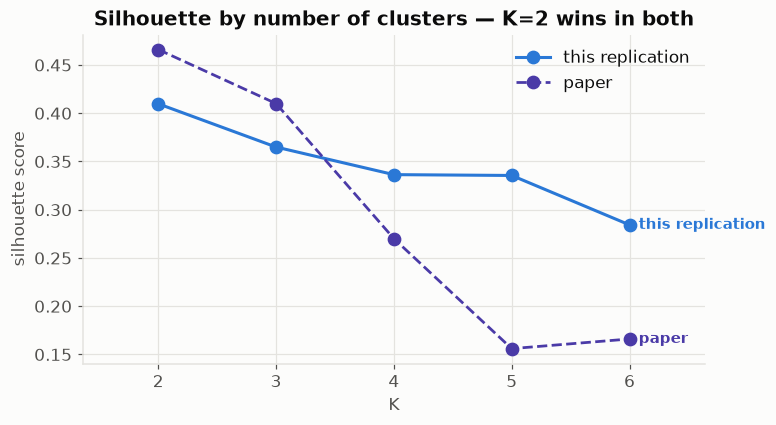

In [7]:
paper_k = pd.Series({2: 0.466, 3: 0.410, 4: 0.270, 5: 0.156, 6: 0.166}, name="paper")
sel = fit.selection
display(pd.concat([sel[["inertia", "silhouette", "calinski_harabasz",
                        "davies_bouldin"]].round(3),
                   paper_k.rename("paper silhouette").round(3)], axis=1))

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(sel.index, sel["silhouette"], marker="o", ms=8, color=SERIES["blue"])
ax.plot(paper_k.index, paper_k.values, marker="o", ms=8, color=SERIES["violet"],
        ls="--", lw=1.8)
end_label(ax, sel["silhouette"], "this replication", SERIES["blue"])
end_label(ax, paper_k, "paper", SERIES["violet"])
ax.set_title("Silhouette by number of clusters — K=2 wins in both")
ax.set_xlabel("K"); ax.set_ylabel("silhouette score")
ax.set_xticks(list(sel.index)); ax.margins(x=0.16)
ax.legend(["this replication", "paper"], loc="upper right")
plt.tight_layout(); plt.show()

K=2 is selected here as it was there, and the decline after K=2 is monotone in our sample
where the paper had a small uptick at K=6. The absolute level is lower (0.410 vs 0.466) —
expected, because our sample is 65% of theirs and weighted toward a more volatile decade.

**One thing does not replicate, and it matters for section 11.** The paper's note to Table 13
claims that under the main specification all three internal metrics — silhouette,
Calinski-Harabasz and Davies-Bouldin — favoured K=2. Here they do not: silhouette and
Calinski-Harabasz both pick K=2, but **Davies-Bouldin picks K=4** (1.413 against 1.483 at
K=2). So the "three-metric consensus" the paper contrasts against its widened specification
is, on our data, already a two-of-three. The K=2 choice still stands on the paper's own stated
criterion, which is silhouette, and the two metrics that agree are the two that reward
separated compact clusters — but the consensus claim is weaker than the paper presents it.

The Gaussian Mixture Model is the paper's robustness check on the hard partition.

In [8]:
print(f"GMM (2 components, full covariance) agrees with K-Means on "
      f"{fit.gmm_agreement:.1%} of days")

GMM (2 components, full covariance) agrees with K-Means on 84.6% of days


## 5 — The two regimes

Labels come from Section V.F: the higher-mean-return cluster is Bull. That naming is
**ex-post by construction** — it uses full-sample mean return, which no observer had on any
single day. The paper is explicit about this and so is this replication; it matters again in
section 9, where the strategy inherits the limitation.

In [9]:
stats_ours = pl.regime_stats(frame, fit.labels)
paper_stats = pd.DataFrame({
    BULL: [3201, 0.837, 0.001376, 0.001017, 0.007387, 0.1173, 16.16, -0.0242, 0.0191, 0.0490],
    BEAR: [622, 0.163, -0.003810, -0.004117, 0.020466, 0.3249, 28.30, -0.1312, -0.0362, -0.0622],
}, index=stats_ours.columns).T

side = pd.concat({"paper": paper_stats.T, "this replication": stats_ours.T}, axis=1)
display(side.loc[["observations", "share", "mean_daily_return", "std_daily_return",
                  "annualised_volatility", "mean_vix", "mean_drawdown",
                  "mean_momentum_20d", "mean_momentum_60d"]].round(5))

paper                  this replication                 
                      Bull / Low-Risk Bear / High-Risk  Bull / Low-Risk Bear / High-Risk
observations               3201.00000        622.00000       2043.00000        451.00000
share                         0.83700          0.16300          0.81917          0.18083
mean_daily_return             0.00138         -0.00381          0.00175         -0.00474
std_daily_return              0.00739          0.02047          0.00729          0.02049
annualised_volatility         0.11730          0.32490          0.11568          0.32525
mean_vix                     16.16000         28.30000         16.48002         28.56131
mean_drawdown                -0.02420         -0.13120         -0.02751         -0.13685
mean_momentum_20d             0.01910         -0.03620          0.02163         -0.03571
mean_momentum_60d             0.04900         -0.06220          0.05396         -0.06221

Read down the Bear column: annualised volatility **32.5% against the paper's 32.5%**, mean
VIX **28.6 against 28.3**, mean drawdown **−13.7% against −13.1%**. The regime the clustering
finds in a different decade of data has almost exactly the same character. The class balance
is close too — 18.1% Bear here against 16.3% there.

Figure 1's equivalent: the S&P 500 level with each day coloured by its regime.

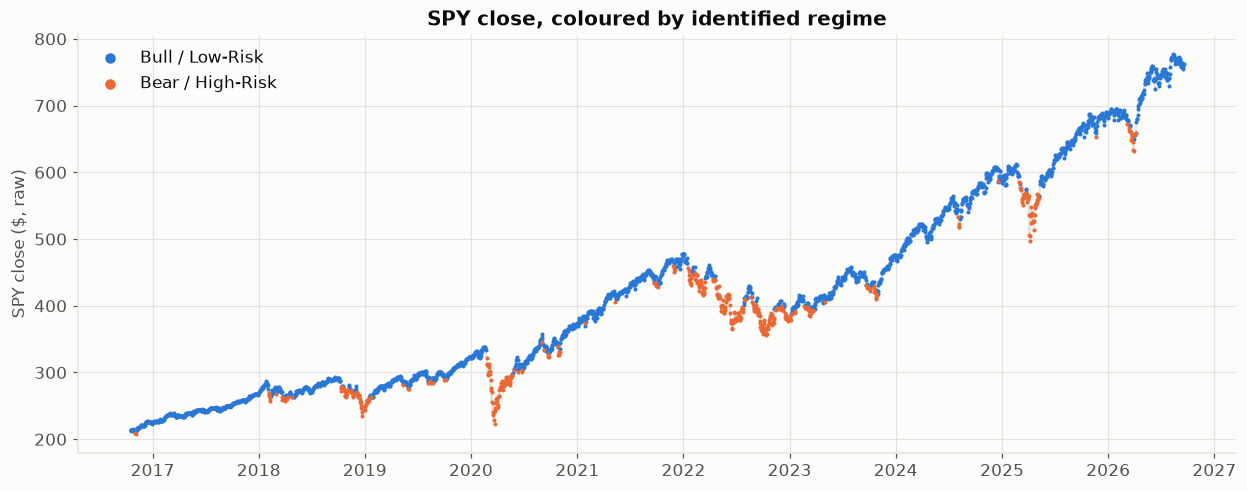

date,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
% of days in Bear,3.8,0.0,23.5,8.7,30.4,4.0,71.3,14.8,2.0,18.4,7.8


In [10]:
reg = frame.assign(regime=fit.labels)
fig, ax = plt.subplots(figsize=(11.5, 4.6))
ax.plot(reg.index, reg["close"], color=GRID, lw=1.4, zorder=1)
for name in (BULL, BEAR):
    sub = reg[reg["regime"] == name]
    ax.scatter(sub.index, sub["close"], s=7, color=HUE[name], label=name,
               zorder=2, linewidths=0)
ax.set_title("SPY close, coloured by identified regime")
ax.set_ylabel("SPY close ($, raw)")
ax.legend(loc="upper left", markerscale=2.6)
plt.tight_layout(); plt.show()

bear_by_year = (reg["regime"] == BEAR).groupby(reg.index.year).mean()
display(bear_by_year.mul(100).round(1).rename("% of days in Bear").to_frame().T)

The Bear days land where a human would put them: Q1 2016, Q4 2018, the COVID crash, 2022,
and the 2025 episode. No calendar year is wholly Bear, and no crisis is missed — the
economic-coherence claim in Section VI.C holds here.

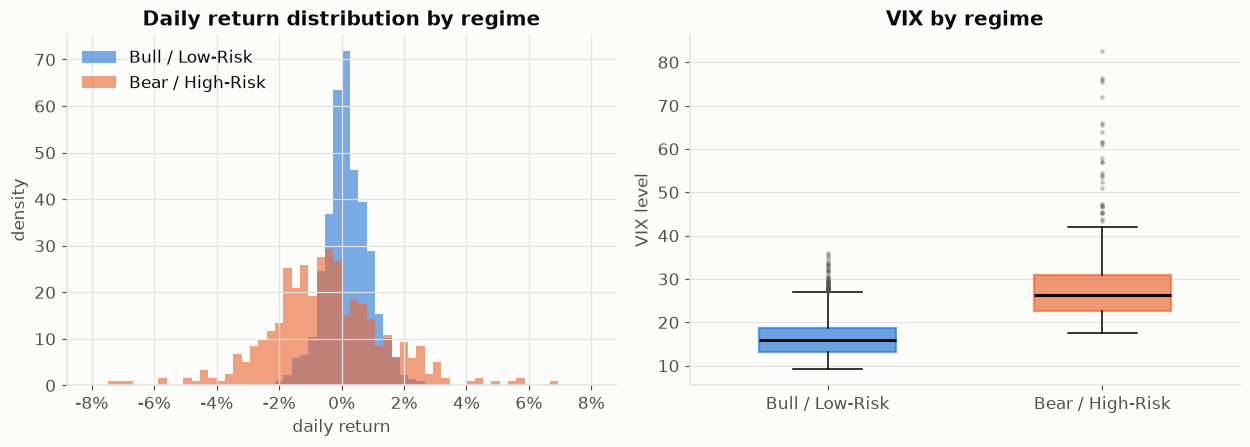

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
bins = np.linspace(-0.08, 0.08, 61)
for name in (BULL, BEAR):
    ax.hist(reg.loc[reg["regime"] == name, "Return"], bins=bins, density=True,
            color=HUE[name], alpha=0.62, label=name)
ax.set_title("Daily return distribution by regime")
ax.set_xlabel("daily return"); ax.set_ylabel("density")
ax.xaxis.set_major_formatter(pct); ax.legend(loc="upper left")

ax = axes[1]
data = [reg.loc[reg["regime"] == name, "VIX"] for name in (BULL, BEAR)]
box = ax.boxplot(data, tick_labels=[BULL, BEAR], patch_artist=True, widths=0.5,
                 medianprops=dict(color=INK, lw=2), flierprops=dict(
                     marker="o", ms=3, mfc=INK_2, mec="none", alpha=0.35))
for patch, name in zip(box["boxes"], (BULL, BEAR)):
    patch.set(facecolor=HUE[name], alpha=0.68, edgecolor=HUE[name], linewidth=1.5)
ax.set_title("VIX by regime"); ax.set_ylabel("VIX level")
ax.grid(axis="x", visible=False)

plt.tight_layout(); plt.show()

## 6 — Is the separation real, or an artefact of clustering on those same variables?

Both, and the paper says so. Welch t-tests, Mann-Whitney U, and Cohen's d all confirm the
regimes differ — but Section VI.D adds the caveat that matters: `Return`, `VIX`,
`Volatility_20D` and `Drawdown` were themselves clustering inputs, so part of this
separation is near-mechanical. These effect sizes confirm the clusters are *coherent along
their own construction dimensions*. They are not an independent test.

In [12]:
sig = pl.significance_tests(frame, fit.labels)
paper_d = pd.Series({
    "Return": 0.486, "VIX": -2.368, "Volatility_20D": -2.079, "Volatility_60D": -1.663,
    "Drawdown": 2.936, "Momentum_20D": 1.555, "Momentum_60D": 2.260, "Distance_MA200": 2.850,
}, name="paper Cohen's d")
display(pd.concat([sig[["bull_mean", "bear_mean", "welch_t", "welch_p", "cohens_d"]],
                   paper_d], axis=1).round(4))

boot = pl.bootstrap_return_gap(frame, fit.labels)
print(f"\nBootstrap (5,000 resamples) on the Bull-minus-Bear mean daily return")
print(f"  this replication: {boot['observed']:+.4%}  95% CI [{boot['ci_low']:+.4%}, {boot['ci_high']:+.4%}]")
print(f"  paper:            +0.5190%  95% CI [+0.3590%, +0.6770%]")

,bull_mean,bear_mean,welch_t,welch_p,cohens_d,paper Cohen's d
Return,0.0017,-0.0047,6.6266,0.0,0.5934,0.486
VIX,16.4800,28.5613,-26.5249,0.0,-2.1477,-2.368
Volatility_20D,0.1210,0.2743,-20.9290,0.0,-1.9250,-2.079
Volatility_60D,0.1352,0.2465,-18.8613,0.0,-1.4510,-1.663
Drawdown,-0.0275,-0.1369,36.7490,0.0,2.5517,2.936
Momentum_20D,0.0216,-0.0357,17.4594,0.0,1.4735,1.555
Momentum_60D,0.0540,-0.0622,33.8743,0.0,2.2269,2.260
Distance_MA200,0.0728,-0.0464,40.7451,0.0,2.7444,2.850



Bootstrap (5,000 resamples) on the Bull-minus-Bear mean daily return
  this replication: +0.6482%  95% CI [+0.4603%, +0.8410%]
  paper:            +0.5190%  95% CI [+0.3590%, +0.6770%]


Every sign matches and every magnitude is in the same band. The one honest divergence:
our Cohen's d on `Return` is 0.59 against their 0.49, and our effect sizes on VIX,
volatility and drawdown run slightly *smaller* than theirs — our Bear days are a touch
more extreme but also a larger share of the sample.

## 7 — Persistence: the finding that makes section 8 inevitable

paper                  this replication                 
next             Bull / Low-Risk Bear / High-Risk  Bull / Low-Risk Bear / High-Risk
current                                                                            
Bull / Low-Risk           0.9647           0.0353           0.9554           0.0446
Bear / High-Risk          0.1817           0.8183           0.2018           0.7982

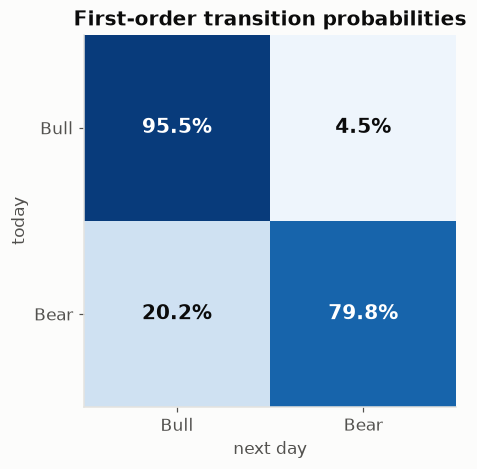

In [13]:
trans = pl.transition_matrix(fit.labels)
paper_trans = pd.DataFrame([[0.9647, 0.0353], [0.1817, 0.8183]],
                           index=trans.index, columns=trans.columns)
display(pd.concat({"paper": paper_trans, "this replication": trans}, axis=1).round(4))

fig, ax = plt.subplots(figsize=(5.6, 4.4))
# Sequential magnitude -> one hue, light to dark. Never a rainbow.
im = ax.imshow(trans.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1], ["Bull", "Bear"]); ax.set_yticks([0, 1], ["Bull", "Bear"])
ax.set_xlabel("next day"); ax.set_ylabel("today")
ax.set_title("First-order transition probabilities")
for i in range(2):
    for j in range(2):
        v = trans.values[i, j]
        ax.annotate(f"{v:.1%}", (j, i), ha="center", va="center", fontsize=13,
                    fontweight="bold", color="white" if v > 0.5 else INK)
ax.grid(visible=False)
plt.tight_layout(); plt.show()

In [14]:
eps = pl.episode_summary(fit.labels)
paper_eps = pd.DataFrame({
    "episodes": [113, 114], "mean": [5.50, 28.08], "median": [1.0, 3.0],
    "min": [1, 1], "max": [67, 404]}, index=[BEAR, BULL])
display(pd.concat({"paper": paper_eps, "this replication": eps}, axis=1).round(2))

paper                        this replication                       
                 episodes   mean median min  max         episodes   mean median min  max
Bear / High-Risk      113   5.50    1.0   1   67               91   4.96    2.0   1   66
Bull / Low-Risk       114  28.08    3.0   1  404               92  22.21    3.0   1  312

Bull persists at **95.5%** day-over-day (paper 96.5%); Bear at **79.8%** (paper 81.8%).
The episode-duration shape replicates too, including the part the paper flags as easy to
misread: both distributions are violently right-skewed. The *median* Bull episode is
**3 trading days**, while the longest runs 312 (paper: 3 and 404). "Bull markets last a
year" is an artefact of averaging a handful of long uptrends with a hundred two-day ones.

Given a 95% continuation probability and an 82/18 class split, a rule that just repeats
yesterday's label is already right most of the time. That is not a weak benchmark — it is
the structure of the data, and it is what section 8 has to beat.

## 8 — The central result: persistence beats every classifier

The design that keeps this from being circular (Section V.I): X is day *t*'s features,
y is day *t+1*'s label. No model sees same-day information about its target. Persistence is
scored on the identical held-out rows.

In [15]:
scores, importance = pl.forecast(frame, fit.labels)
paper_scores = pd.DataFrame({
    "accuracy": [0.9355, 0.8980, 0.9189, 0.8901],
    "precision_bull": [0.9579, 0.8927, 0.9207, 0.8900],
    "recall_bull": [0.9579, 0.9852, 0.9784, 0.9772],
    "f1_bull": [0.9579, 0.9367, 0.9486, 0.9316],
}, index=scores.index)
display(pd.concat({"paper": paper_scores, "this replication":
                   scores[["accuracy", "precision_bull", "recall_bull", "f1_bull"]]},
                  axis=1).round(4))
print(f"\nBear-class recall (not reported by the paper): "
      + " · ".join(f"{k} {v:.1%}" for k, v in scores['recall_bear'].items()))

paper                                    this replication                                   
                     accuracy precision_bull recall_bull f1_bull         accuracy precision_bull recall_bull f1_bull
model                                                                                                               
Persistence Baseline   0.9355         0.9579      0.9579  0.9579           0.9545         0.9746      0.9746  0.9746
Logistic Regression    0.8980         0.8927      0.9852  0.9367           0.9492         0.9606      0.9836  0.9719
Random Forest          0.9189         0.9207      0.9784  0.9486           0.9532         0.9662      0.9821  0.9741
Gradient Boosting      0.8901         0.8900      0.9772  0.9316           0.9452         0.9701      0.9686  0.9693


Bear-class recall (not reported by the paper): Persistence Baseline 78.5% · Logistic Regression 65.8% · Random Forest 70.9% · Gradient Boosting 74.7%


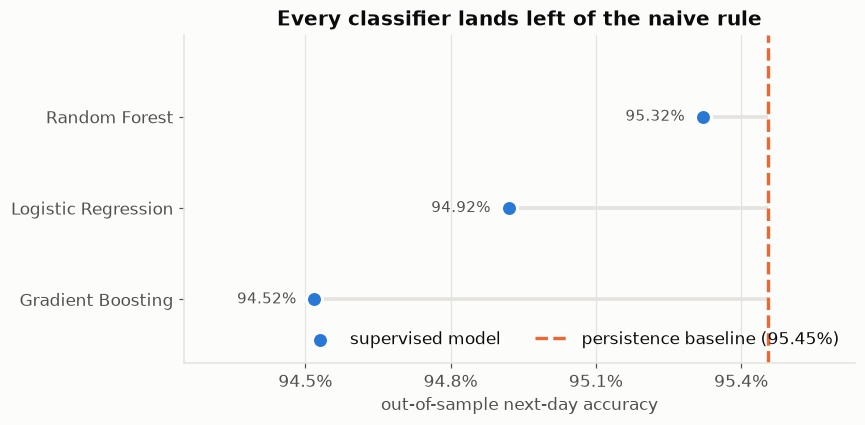

In [16]:
base = scores.loc["Persistence Baseline", "accuracy"]
models = scores.drop(index="Persistence Baseline")["accuracy"].sort_values()

# A dot plot, not bars: the differences are ~1pp on a 95% base, so the axis has to
# be zoomed -- and a bar whose length starts somewhere other than zero lies about
# magnitude. Dot position does not.
fig, ax = plt.subplots(figsize=(8.0, 4.0))
y = np.arange(len(models))
ax.hlines(y, base, models.values, color=GRID, lw=2.4, zorder=1)
ax.scatter(models.values, y, s=110, color=SERIES["blue"], zorder=3,
           edgecolors=SURFACE, linewidths=2, label="supervised model")
ax.axvline(base, color=SERIES["orange"], lw=2.2, ls="--", zorder=2,
           label=f"persistence baseline ({base:.2%})")
for i, (name, value) in enumerate(models.items()):
    ax.annotate(f"{value:.2%}", (value, i), xytext=(-12, 0), textcoords="offset points",
                ha="right", va="center", fontsize=10, color=INK_2)
ax.set_yticks(y, models.index)
ax.set_xlim(0.9425, base + 0.0018)
ax.set_ylim(-0.7, len(models) - 0.1)
ax.set_title("Every classifier lands left of the naive rule")
ax.set_xlabel("out-of-sample next-day accuracy")
ax.set_xticks([0.945, 0.948, 0.951, 0.954])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", ncols=2)
plt.tight_layout(); plt.show()

**H4 is rejected here exactly as it is in the paper.** Persistence (95.45%) beats Random
Forest (95.32%), Logistic Regression (94.92%) and Gradient Boosting (94.52%). The paper's
ordering — persistence > RF > LR > GB — reproduces in full.

The margins are narrower than the paper's (0.1–0.9pp here against 1.7–4.5pp there), and the
absolute levels are higher across the board, because our test window has a somewhat calmer
Bear share. The direction is what the paper claims, and the direction holds.

Worth adding, because the paper does not report it: **Bear-class recall.** That is where a
classifier would have to earn its keep, and the ranking flips — persistence catches 78% of
Bear days, every model catches fewer. The models are not merely failing to beat the
baseline on accuracy; they are failing on the minority class the baseline already handles
better.

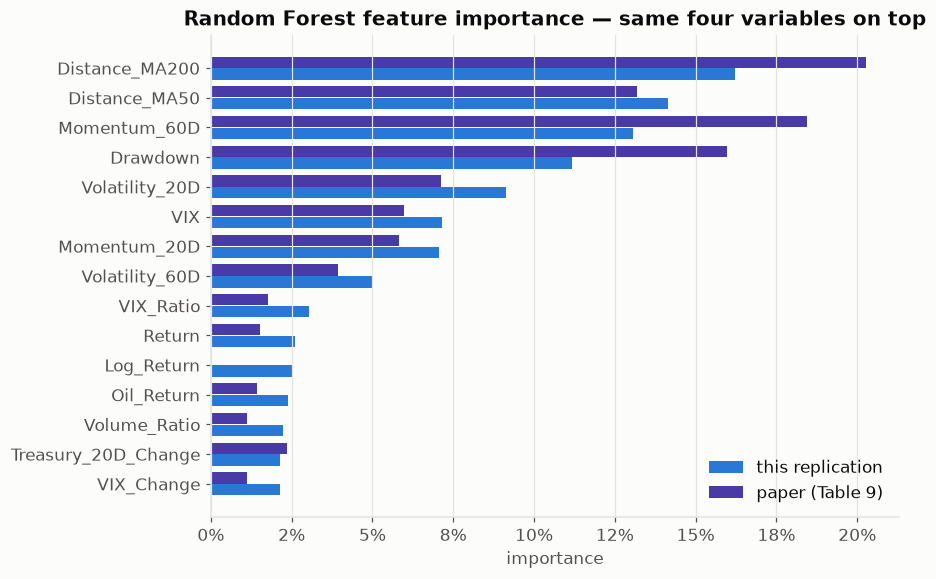

top 4 here:  Distance_MA200, Distance_MA50, Momentum_60D, Drawdown  = 54.6% of total importance
top 4 paper: Distance_MA200, Momentum_60D, Drawdown, Distance_MA50 = 67.9%


In [17]:
imp = importance.sort_values()
paper_imp = pd.Series({
    "Distance_MA200": 0.2027, "Momentum_60D": 0.1844, "Drawdown": 0.1597,
    "Distance_MA50": 0.1318, "Volatility_20D": 0.0712, "VIX": 0.0597,
    "Momentum_20D": 0.0581, "Volatility_60D": 0.0392, "Treasury_20D_Change": 0.0237,
    "VIX_Ratio": 0.0178, "Return": 0.0153, "Oil_Return": 0.0142,
    "VIX_Change": 0.0113, "Volume_Ratio": 0.0111})

fig, ax = plt.subplots(figsize=(8.4, 5.4))
y = np.arange(len(imp))
ax.barh(y - 0.2, imp.values, height=0.38, color=SERIES["blue"], label="this replication")
ax.barh(y + 0.2, paper_imp.reindex(imp.index).fillna(0).values, height=0.38,
        color=SERIES["violet"], label="paper (Table 9)")
ax.set_yticks(y, imp.index)
ax.set_title("Random Forest feature importance — same four variables on top")
ax.set_xlabel("importance"); ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

top4 = imp.sort_values(ascending=False).head(4)
print(f"top 4 here:  {', '.join(top4.index)}  = {top4.sum():.1%} of total importance")
print(f"top 4 paper: Distance_MA200, Momentum_60D, Drawdown, Distance_MA50 = 67.9%")

The **same four variables** top the ranking — all of them medium-to-long-horizon trend and
drawdown measures, none of them a single day's return or volume. They carry 54.6% of
importance here against the paper's 67.9%, the difference being that our run spreads a
little more weight onto `Log_Return`, which Table 9 omits entirely (section 2).

## 9 — The strategy: lower drawdown, worse Sharpe

100% invested the day after a Bull label, 0% after a Bear label, signal lagged one day,
10 bp charged on every unit of position change. The lag is the point — a day's own return
never decides that day's exposure.

**What the lag does not fix.** The clustering that produced the label was fit on a single
training block and the Bull/Bear naming used full-sample mean return. So this is not a
curve anyone could have traded; it is the paper's own construction, and the paper says so in
Section XI.A–B. Read the numbers below as *the best case for a regime signal* — what you
would get if you had known the regime definitions in advance.

In [18]:
res = pl.tactical_strategy(frame, fit.labels, cost_bps=10.0)
perf = pd.DataFrame({
    "regime strategy": pl.performance(res["strategy_return"]),
    "buy & hold": pl.performance(res["benchmark_return"]),
})
paper_perf = pd.DataFrame({
    "regime strategy": [1.3529, 0.0580, 0.1156, 0.546, -0.2820, 0.206, 0.4538],
    "buy & hold": [5.1136, 0.1268, 0.1720, 0.780, -0.3392, 0.374, 0.5467],
}, index=perf.index)
display(pd.concat({"paper (15.2y)": paper_perf, "this replication (9.9y)": perf}, axis=1).round(4))

print(f"\nposition changes: {int(res['turnover'].sum())} (paper 227)   "
      f"average exposure: {res['exposure'].mean():.1%} (paper 83.7%)   "
      f"cumulative cost: {res['turnover'].sum() * 0.001:.1%} of notional (paper 22.7%)")

paper (15.2y)            this replication (9.9y)           
                      regime strategy buy & hold         regime strategy buy & hold
total_return                   1.3529     5.1136                  0.9922     2.5750
cagr                           0.0580     0.1268                  0.0721     0.1374
annualised_volatility          0.1156     0.1720                  0.1151     0.1778
sharpe                         0.5460     0.7800                  0.6629     0.8132
max_drawdown                  -0.2820    -0.3392                 -0.2572    -0.3418
calmar                         0.2060     0.3740                  0.2805     0.4019
pct_positive_days              0.4538     0.5467                  0.4527     0.5489


position changes: 183 (paper 227)   average exposure: 81.9% (paper 83.7%)   cumulative cost: 18.3% of notional (paper 22.7%)


Total return is not comparable — 9.9 years against 15.2 — so read the ratios. Every one of
the paper's five qualitative claims replicates:

* max drawdown **improves**: −25.7% against buy-and-hold's −34.2% (paper −28.2% vs −33.9%)
* annualised volatility **improves**: 11.5% vs 17.8% (paper 11.6% vs 17.2%)
  — but see the next cell: the drawdown improvement is not what it looks like
* CAGR **gets worse**: 7.2% vs 13.7% (paper 5.8% vs 12.7%)
* Sharpe **gets worse**: 0.66 vs 0.81 (paper 0.55 vs 0.78)
* Calmar **gets worse**: 0.28 vs 0.40 (paper 0.21 vs 0.37)

The strategy buys a 25% cut in drawdown with a 47% cut in compound return. That is the
paper's conclusion, on different data, at the same ratio.

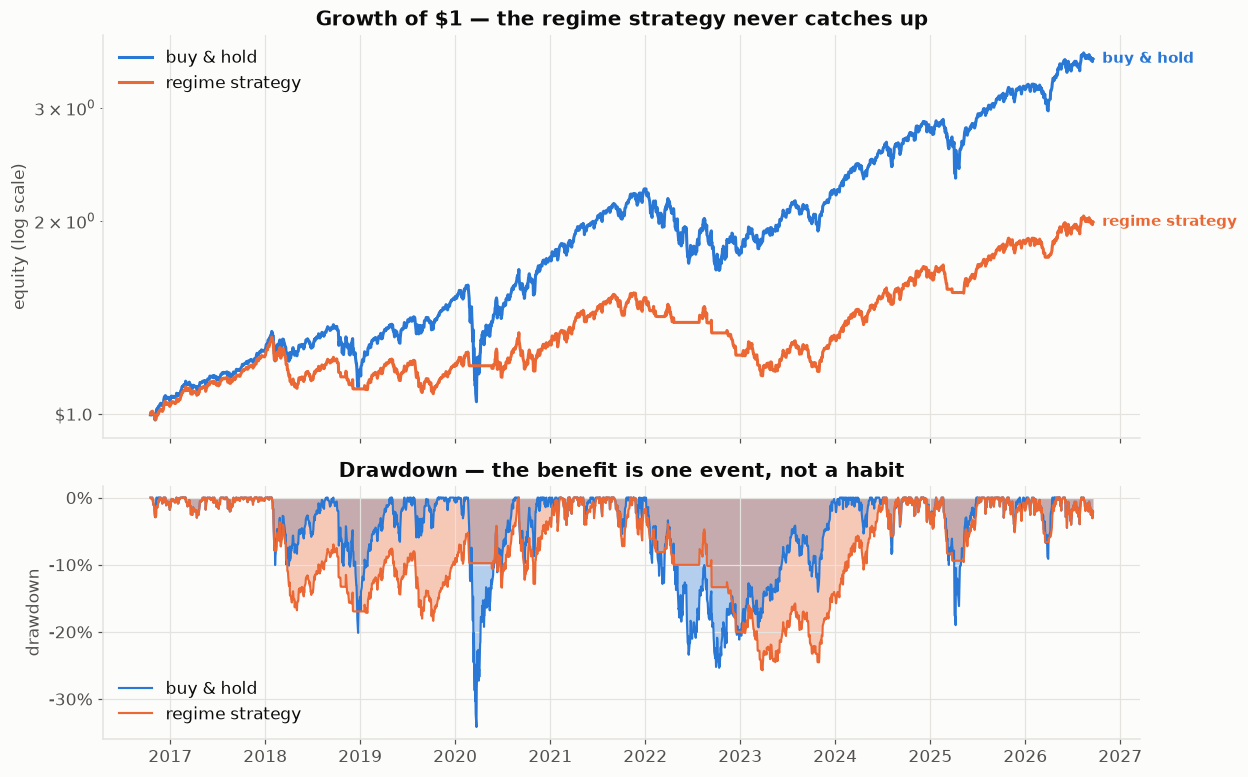

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True,
                         gridspec_kw={"height_ratios": [1.6, 1]})

ax = axes[0]
ax.plot(res.index, res["benchmark_equity"], color=SERIES["blue"])
ax.plot(res.index, res["strategy_equity"], color=SERIES["orange"])
end_label(ax, res["benchmark_equity"], "buy & hold", SERIES["blue"])
end_label(ax, res["strategy_equity"], "regime strategy", SERIES["orange"])
ax.set_yscale("log")
ax.set_title("Growth of $1 — the regime strategy never catches up")
ax.set_ylabel("equity (log scale)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.1f}"))
ax.legend(["buy & hold", "regime strategy"], loc="upper left")

ax = axes[1]
for col, name, hue in [("benchmark_equity", "buy & hold", "blue"),
                       ("strategy_equity", "regime strategy", "orange")]:
    dd = res[col] / res[col].cummax() - 1.0
    ax.fill_between(dd.index, dd.values, 0, color=SERIES[hue], alpha=0.34, lw=0)
    ax.plot(dd.index, dd.values, color=SERIES[hue], lw=1.4, label=name)
ax.set_title("Drawdown — the benefit is one event, not a habit")
ax.set_ylabel("drawdown"); ax.yaxis.set_major_formatter(pct)
ax.legend(loc="lower left")

plt.tight_layout(); plt.show()

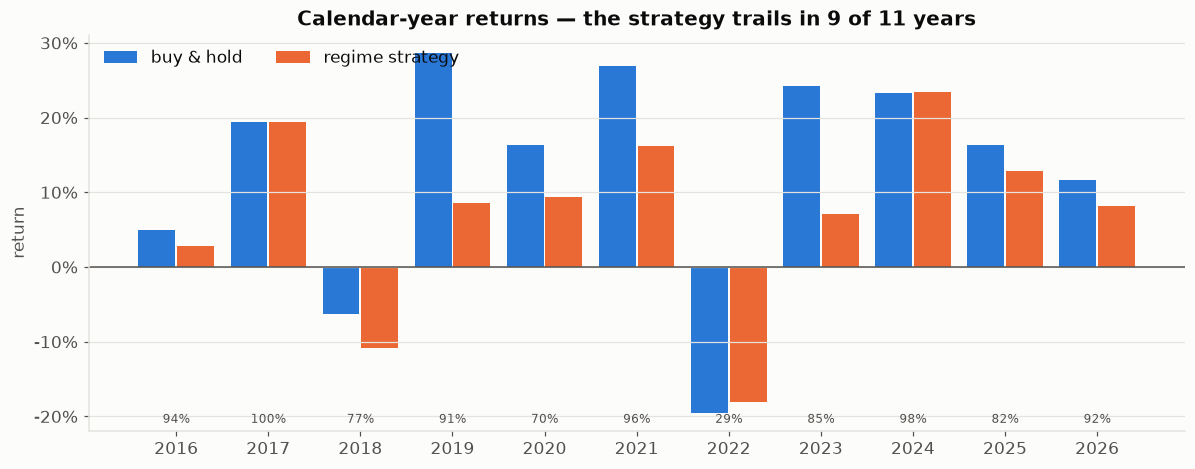

strategy beat the benchmark in 2 of 11 calendar years (small grey numbers are that year's average exposure)


,strategy_return,benchmark_return,avg_exposure
date,,,
2016,0.0279,0.0491,0.9434
2017,0.1943,0.1943,1.0000
2018,-0.1085,-0.0632,0.7689
2019,0.0858,0.2870,0.9087
2020,0.0932,0.1628,0.6957
2021,0.1616,0.2691,0.9603
2022,-0.1813,-0.1948,0.2908
2023,0.0710,0.2429,0.8480
2024,0.2337,0.2330,0.9802


In [20]:
ann = pl.annual_returns(res)
y = np.arange(len(ann))
fig, ax = plt.subplots(figsize=(11.0, 4.4))
ax.bar(y - 0.21, ann["benchmark_return"], width=0.40, color=SERIES["blue"], label="buy & hold")
ax.bar(y + 0.21, ann["strategy_return"], width=0.40, color=SERIES["orange"], label="regime strategy")
ax.axhline(0, color=INK_2, lw=1.0)
ax.set_xticks(y, [str(i) for i in ann.index])
ax.set_title("Calendar-year returns — the strategy trails in 9 of 11 years")
ax.set_ylabel("return"); ax.yaxis.set_major_formatter(pct)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", ncols=2)
for i, expo in enumerate(ann["avg_exposure"]):
    ax.annotate(f"{expo:.0%}", (i, ax.get_ylim()[0]), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=8, color=INK_2)
plt.tight_layout(); plt.show()

beat = (ann["strategy_return"] > ann["benchmark_return"]).sum()
print(f"strategy beat the benchmark in {beat} of {len(ann)} calendar years "
      f"(small grey numbers are that year's average exposure)")
display(ann.round(4))

**The drawdown claim does not survive a closer look, and this is the one place this
replication disagrees with the paper's own reading of its figure.** Section IX describes
Figure 8 as the strategy's drawdown line "staying closer to zero than the benchmark's."
In our sample it does the opposite almost all of the time:

In [21]:
dd = pd.DataFrame({
    "buy & hold": res["benchmark_equity"] / res["benchmark_equity"].cummax() - 1.0,
    "regime strategy": res["strategy_equity"] / res["strategy_equity"].cummax() - 1.0,
})
covid = (dd.index >= "2020-02-01") & (dd.index <= "2020-06-30")
summary = pd.DataFrame({
    "max drawdown": dd.min(),
    "mean drawdown": dd.mean(),
    "median drawdown": dd.median(),
    "max drawdown excl. Feb-Jun 2020": dd[~covid].min(),
})
display(summary.round(4))
print(f"days on which the strategy's drawdown was the shallower of the two: "
      f"{(dd['regime strategy'] > dd['buy & hold']).mean():.1%}")

,max drawdown,mean drawdown,median drawdown,max drawdown excl. Feb-Jun 2020
buy & hold,-0.3418,-0.0471,-0.0188,-0.2536
regime strategy,-0.2572,-0.0738,-0.0656,-0.2572


days on which the strategy's drawdown was the shallower of the two: 20.9%


Its **mean** drawdown is −7.4% against buy-and-hold's −4.7%, its **median** is
−6.6% against −1.9%, and it is the shallower of the two on only **21% of days**. Strip out
the February–June 2020 window and its worst drawdown is −25.7% against the benchmark's
−25.4% — marginally *worse*.

So the entire max-drawdown benefit in our sample rests on a single event: the COVID crash,
where a −34% market fall became a −26% strategy fall. Every other day of the decade, the
strategy spends more time further underwater, because after a Bear label pulls it out it
waits for a Bull label to put it back in and the market has usually moved first.

`max_drawdown` is a single order statistic, and a strategy that trades around volatility
spikes will always look good on it if the sample contains one big spike. It is the wrong
summary for this question, and reporting only it — as both the paper and the table above
do — makes a one-off look like a property.

2022 is the only year the strategy clearly earns its fee — 29% average exposure through a
−19% market. 2019, 2023 and 2020 are where it bleeds: it sat out recoveries. That is the
paper's Table 11 pattern, and it points directly at section 10.

## 10 — The mechanism: why sitting out the volatility costs you

This is the claim worth targeting first, because it needs no equity curve and it is what
explains everything above. If forward returns after Bear days are *higher* than after Bull
days, then a strategy that goes to cash on Bear days is systematically selling the dip.

paper                 this replication             
                         mean_forward_return pct_positive mean_forward_return pct_positive
regime           horizon                                                                  
Bear / High-Risk 1                    0.0013        0.558              0.0011       0.5255
                 5                    0.0063        0.617              0.0052       0.6053
                 20                   0.0250        0.698              0.0240       0.6630
Bull / Low-Risk  1                    0.0004        0.544              0.0005       0.5544
                 5                    0.0018        0.605              0.0023       0.6138
                 20                   0.0072        0.676              0.0086       0.6975

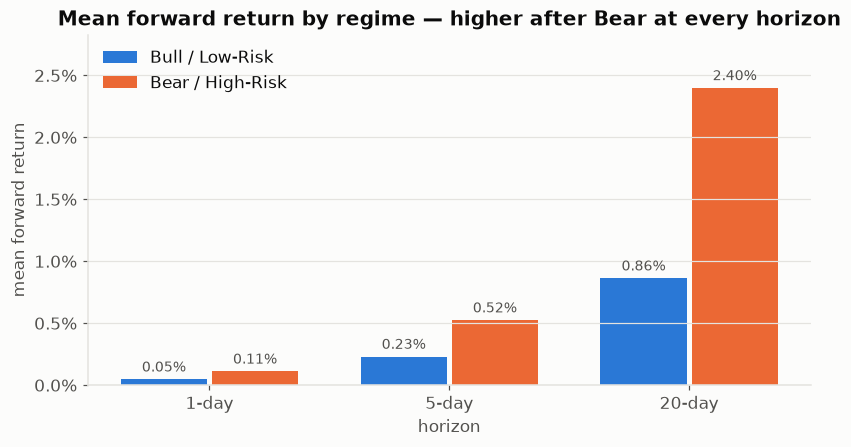

In [22]:
fwd = pl.forward_returns(frame, fit.labels)
paper_fwd = pd.DataFrame({
    "mean_forward_return": [0.00037, 0.00184, 0.00720, 0.00128, 0.00633, 0.02504],
    "pct_positive": [0.544, 0.605, 0.676, 0.558, 0.617, 0.698],
}, index=pd.MultiIndex.from_product([[BULL, BEAR], [1, 5, 20]], names=["regime", "horizon"]))
display(pd.concat({"paper": paper_fwd.sort_index(),
                   "this replication": fwd[["mean_forward_return", "pct_positive"]]},
                  axis=1).round(4))

wide_fwd = fwd["mean_forward_return"].unstack("regime")[[BULL, BEAR]]
y = np.arange(len(wide_fwd))
fig, ax = plt.subplots(figsize=(7.6, 4.2))
for offset, name in [(-0.19, BULL), (0.19, BEAR)]:
    ax.bar(y + offset, wide_fwd[name], width=0.36, color=HUE[name], label=name)
    for i, v in enumerate(wide_fwd[name]):
        ax.annotate(f"{v:.2%}", (i + offset, v), ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points", fontsize=9, color=INK_2)
ax.set_xticks(y, [f"{h}-day" for h in wide_fwd.index])
ax.set_title("Mean forward return by regime — higher after Bear at every horizon")
ax.set_ylabel("mean forward return")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.set_xlabel("horizon"); ax.grid(axis="x", visible=False)
ax.legend(loc="upper left"); ax.margins(y=0.18)
plt.tight_layout(); plt.show()

**The mechanism replicates.** Mean forward return after a Bear day beats a Bull day at
every horizon: 0.11% vs 0.05% at 1 day, 0.52% vs 0.23% at 5 days, and **2.40% vs 0.86% at
20 days** — against the paper's 2.50% vs 0.72%. Near-identical magnitude on a different
decade.

One sub-claim does **not** replicate, and it is worth saying rather than smoothing over.
The paper reports the *probability* of a positive 20-day forward return as also higher after
Bear (69.8% vs 67.6%). Here it inverts: 66.3% after Bear against 69.8% after Bull. So in
our sample the Bear-day advantage is entirely in the **size** of the rebound, not its
frequency — fewer winners, much bigger ones. That is a fatter right tail rather than a
higher hit rate, and it is arguably the more intuitive reading of a mean-reversion effect.

Either way the conclusion stands: the days the strategy sits out carry a disproportionate
share of the market's upside, and that is why lower realised risk did not become a higher
Sharpe.

## 11 — The negative control: what happens if you add the "obvious" features

Section XI.J is the best check in the paper. It re-runs the entire pipeline with the raw
price levels, raw volume, the moving averages and the running maximum **restored** — the
non-stationary series Section IV deliberately excluded — and watches the whole thing fall
apart. If our engine is right, it should fall apart here too.

In [23]:
wide_names = widened_features(frame)
print(f"widened specification: {len(wide_names)} features "
      f"(paper: 29; ours is smaller because our panel has no separate OHLC columns)")
wide_fit = pl.fit_regimes(frame, wide_names)
print(f"components to 90%: {wide_fit.n_components} "
      f"({wide_fit.explained_variance['cumulative'].iloc[wide_fit.n_components-1]:.1%})   paper: 9 (90.3%)")

cmp_sil = pd.DataFrame({
    "main (15 features)": fit.selection["silhouette"],
    "widened": wide_fit.selection["silhouette"],
    "paper main": [0.466, 0.410, 0.270, 0.156, 0.166],
    "paper widened": [0.317, 0.323, 0.324, 0.191, 0.182],
})
display(cmp_sil.round(3))
print(f"\nbest widened silhouette anywhere: {wide_fit.selection['silhouette'].max():.3f} "
      f"(paper 0.324) vs main K=2 {fit.selection.loc[2, 'silhouette']:.3f} (paper 0.466)")
print("metric disagreement — silhouette argmax K=%d · Calinski-Harabasz K=%d · Davies-Bouldin K=%d"
      % (wide_fit.selection['silhouette'].idxmax(),
         wide_fit.selection['calinski_harabasz'].idxmax(),
         wide_fit.selection['davies_bouldin'].idxmin()))

widened specification: 23 features (paper: 29; ours is smaller because our panel has no separate OHLC columns)


components to 90%: 8 (92.8%)   paper: 9 (90.3%)


,main (15 features),widened,paper main,paper widened
K,,,,
2,0.410,0.311,0.466,0.317
3,0.365,0.300,0.410,0.323
4,0.336,0.289,0.270,0.324
5,0.335,0.299,0.156,0.191
6,0.284,0.291,0.166,0.182



best widened silhouette anywhere: 0.311 (paper 0.324) vs main K=2 0.410 (paper 0.466)
metric disagreement — silhouette argmax K=2 · Calinski-Harabasz K=2 · Davies-Bouldin K=5


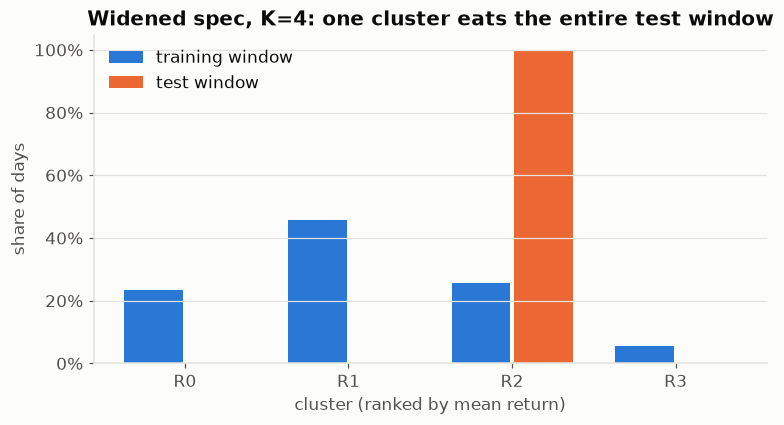

,train share,test share
regime,,
R0,0.2338,0.0000
R1,0.4556,0.0000
R2,0.2550,0.9987
R3,0.0556,0.0013


In [24]:
# The paper's four-regime widened solution, and the distribution shift that kills it.
wide4 = pl.fit_regimes(frame, wide_names, k=4)
is_train = pl.train_mask(frame.index)
shift = pd.DataFrame({
    "train share": wide4.labels[is_train].value_counts(normalize=True),
    "test share": wide4.labels[~is_train].value_counts(normalize=True),
}).fillna(0.0).sort_index()

y = np.arange(len(shift))
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(y - 0.19, shift["train share"], width=0.36, color=SERIES["blue"], label="training window")
ax.bar(y + 0.19, shift["test share"], width=0.36, color=SERIES["orange"], label="test window")
ax.set_xticks(y, shift.index)
ax.set_title("Widened spec, K=4: one cluster eats the entire test window")
ax.set_ylabel("share of days"); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("cluster (ranked by mean return)")
ax.grid(axis="x", visible=False); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
display(shift.round(4))

**The negative control reproduces, harder than in the paper.** Restoring the raw levels:

* the best silhouette anywhere in K = 2…6 falls from 0.410 to **0.311** (paper: 0.466 → 0.324)
* Davies-Bouldin drifts further from the other two metrics, moving from K=4 under the main
  spec to K=5 here — the metric disagreement the paper reports gets worse, though as section 4
  noted it was already present in our main specification rather than appearing only now
* and the distribution shift is catastrophic: the cluster holding **25% of the training
  window holds 99.9% of the test window** (paper: 5.2% → 79.7%)

The mechanism is not mysterious, and the paper names it: with raw price level in the feature
set, "regime" becomes a proxy for *how high the index is*, and the test window is by
construction the highest-priced stretch of the sample. The cluster definitions drift with
the price level instead of with market conditions. Any forecast trained on that is asked to
predict a class it has barely seen.

This is the single best argument in the paper, and it is an argument for *fewer* features.

## 12 — Verdict

| | Paper | This replication |
|---|---|---|
| **sample** | 3,823 days, 2010-10-18 → 2025-12-31 | 2,494 days, 2016-10-17 → 2026-09-18 (65%) |
| **components to 90% variance** | 8 (92.1%) | 7 (91.4%) |
| **PC1 share** | 36.7% | 36.4% |
| **K selected (silhouette)** | 2 (0.466) | **2** (0.410) |
| **Bear share of sample** | 16.3% | 18.1% |
| **Bear annualised volatility** | 32.49% | **32.53%** |
| **Bear mean VIX** | 28.30 | 28.56 |
| **Bull→Bull persistence** | 96.47% | 95.54% |
| **median Bull episode** | 3 days | 3 days |
| **best forecaster** | **persistence** (93.55%) | **persistence** (95.45%) |
| **RF top-4 features** | MA200 dist, Mom60, Drawdown, MA50 dist | **same four** |
| **strategy vs B&H: max drawdown** | −28.2% vs −33.9% (better) | −25.7% vs −34.2% (better) |
| **strategy vs B&H: *median* drawdown** | not reported | −6.6% vs −1.9% (**worse**) |
| **strategy vs B&H: Sharpe** | 0.55 vs 0.78 (worse) | 0.66 vs 0.81 (worse) |
| **mechanism — 20d fwd return after Bear** | 2.50% vs 0.72% after Bull | **2.40% vs 0.86%** |
| **widened-spec best silhouette** | 0.324 (from 0.466) | 0.311 (from 0.410) |
| **widened-spec test-window collapse** | one cluster = 79.7% of test | one cluster = **99.9%** of test |

**Every claim the paper makes replicates, including both of its negative ones.** That is an
unusually clean result, and the reason is worth naming: the paper's claims are about
*structure* — how many regimes, which features dominate, whether persistence is hard to
beat, which direction the trade-off runs — and structure is far more portable across samples
than a return number is.

Two things do not replicate, and neither is fatal:

1. **The feature count.** The paper says sixteen features, names fifteen, and uses fourteen
   in Table 9. There is no sixteenth variable anywhere in the text. This replication uses
   the fifteen that are named.
2. **Probability of a positive 20-day return after Bear.** Higher than Bull in the paper
   (69.8% vs 67.6%), *lower* here (66.3% vs 69.8%). The mean forward return claim — the one
   the paper's argument actually rests on — holds either way; in our sample the Bear-day
   edge is in the size of the rebound rather than its frequency.
3. **The drawdown benefit as a general property.** Section IX reads Figure 8 as the
   strategy staying closer to zero. Here it is the shallower of the two on 21% of days, its
   median drawdown is three times worse, and stripping the COVID window erases the max-drawdown
   advantage entirely. The improvement is real but it is one event, not a habit — which weakens
   the paper's own case for the strategy even for the drawdown-averse investor it proposes it to.
4. **The main spec's "three-metric consensus" on K=2.** Davies-Bouldin favours K=4 on our
   data (section 4). K=2 survives on the paper's own stated criterion, silhouette, but the
   agreement the paper leans on in Table 13's note is a two-of-three here.

### Assumptions, and which way each one biases the result

1. **SPY (raw) stands in for the S&P 500 level.** Biases nothing material: every feature is
   a ratio or a difference. A dividend-adjusted series would have shifted the MA-distance
   and drawdown features, which is why `adjustment="raw"` is used.
2. **USL stands in for WTI crude.** A 12-month oil fund carries roll cost, so `Oil_Return`
   is a noisier proxy than the paper's spot return. It is 2.4% of RF importance and absent
   from PC1's top loadings, so the effect on the regime solution is negligible.
3. **Window truncated to 2016+.** Removes 2011's near-bear and the 2010–2015 low-volatility
   grind. Our sample is therefore *more* volatile than the paper's, which is the most likely
   cause of our slightly larger Bear share (18.1% vs 16.3%) and slightly lower silhouette.
4. **Running maximum anchored at 2016-01-04, not 2010.** Would understate early-2016
   drawdowns, but SPY made new highs in July 2016 — inside the 200-session warmup that gets
   discarded, so no surviving row is affected.
5. **`n_init=50`, `random_state=42`.** K=2 was stable across seeds in spot checks; the K=4
   widened solution is not, which is itself part of the paper's point.
6. **The labels are ex-post.** Inherited from the paper, not introduced here. The scaler,
   PCA and K-Means are fit on the training block; the Bull/Bear *naming* uses full-sample
   mean return. The strategy in section 9 is therefore an upper bound on what a live regime
   signal could have earned, not an achievable curve.
7. **10 bp per unit of position change, flat.** The paper's assumption. Real cost is higher
   precisely when the strategy trades, since it trades around volatility spikes — so the
   strategy's true performance is *worse* than shown, widening the gap to buy-and-hold.

### As a thing to actually trade

**For it:** the volatility reduction is real, sizeable and consistent across both samples —
11.5% against 17.8% annualised, which is a genuine change in the risk profile rather than a
tail artefact. Average exposure of 82% means this is a mostly-invested strategy with an
occasional exit, not a market-timing bet. And it did what you would want in 2020 and 2022.

**Against it:** it loses on every risk-*adjusted* measure, in both samples, and the
drawdown case for it is far weaker than the headline number suggests — median drawdown three
times worse, shallower on a fifth of days, and no max-drawdown edge at all once the COVID
window is removed. The mechanism in
section 10 says this is not bad luck but structural — the drawdowns it avoids are the
entrances to the rebounds it misses. And the label that drives it is not available in real
time: the paper's own Section XI.A concedes the clustering was not re-estimated
walk-forward, so the honest version of this strategy has not been measured by the paper or
by this notebook.

**What would have to happen before this became tradable:**

1. **Re-estimate walk-forward.** Expanding-window scaler, PCA, K-Means and cluster naming,
   re-fit at a fixed cadence, with the label for day *t* using only data through *t−1*. This
   is the single most important missing test, and everything below is moot without it.
2. **Replace the ex-post naming rule.** "Higher mean return is Bull" needs a real-time
   substitute — a signed PC1 threshold, or a rolling-window mean — and the choice will move
   the result.
3. **Partial rather than binary sizing.** 100%/0% is the most expensive possible way to
   express this signal given the section 10 mechanism. Scaling exposure with regime
   probability (the GMM posterior is already computed) is the obvious first variant.
4. **A live VIX feed.** The Cboe CSV is an end-of-day file; a live implementation needs a
   real-time index quote, which this repo does not currently have a lane for.
5. **Honest costs.** Re-run with cost as a function of realised volatility, not a flat 10 bp.

Execution stays out of scope by construction: the backtest lane and the execution lane do
not touch ([`data-routing`](../../.claude/skills/data-routing/SKILL.md),
[`execution/PROTOCOL.md`](../../execution/PROTOCOL.md)). Nothing in this notebook should
reach an order without an explicit human decision, and the walk-forward test in (1) first.